In [35]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Montserrat', 'Helvetica', 'Arial', 'DejaVu Sans']

In [36]:
raymond_reddit_df = pd.read_csv("../reddit_data.csv")
jf_reddit_df = pd.read_csv("../reddit_data_jf.csv")
jf_reddit_df = jf_reddit_df[jf_reddit_df['Intern Notes'] != "not relevant"].drop(columns=["Unnamed: 12"]).copy()
raia_local_df = pd.read_excel("../Phase2_Local.xlsx")
raia_global_df = pd.read_excel("../Phase2_Global.xlsx")
migs_reddit_df = pd.read_excel("../reddit_freelance_ofw_clean.xlsx")

dfs = {
    "raymond": raymond_reddit_df,
    "jf": jf_reddit_df,
    "raia_local": raia_local_df,
    "raia_global": raia_global_df,
    "migs": migs_reddit_df
}

In [37]:
is_all_good = True
for (name1, df1), (name2, df2) in combinations(dfs.items(), 2):
    cols1 = set(df1.columns)
    cols2 = set(df2.columns)

    if cols1 != cols2:
        print(f"{name1} is not the same as {name2}")
        is_all_good = False


if is_all_good:
    print("All the dataframes have the same columns")
    final_df = pd.concat(dfs.values())

final_df['Has Platform'] = final_df['Platform Mentioned'].notna()
theme_map = {
    'GHOSTING': 'Ghosting',
    'PROCESS': 'Complex\nApplication Process',
    'EMOTIONAL': 'Job Search\nBurnout',
    'UX': 'Confusing\nUX',
    'RELEVANCE': 'Lack of\nRelevance',
    'SCAM': 'Possibility\nof Scam',
    'VISIBILITY': 'Lack of\nVisibility',
    'VISIBLITY': 'Lack of\nVisibility',  # typo fix
    'OTHER': 'Other',
    'OVERSEAS': 'Overseas\nExperience',
    'OFW': 'Overseas\nExperience' # encoding fix
}

final_df['Formalized Theme Tag'] = final_df['Theme Tag'].replace(theme_map)


theme_map = {
    'GHOSTING': 'GHOSTING',
    'PROCESS': 'PROCESS',
    'EMOTIONAL': 'EMOTIONAL',
    'UX': 'UX',
    'RELEVANCE': 'RELEVANCE',
    'SCAM': 'SCAM',
    'VISIBILITY': 'VISIBILITY',
    'VISIBLITY': 'VISIBILITY',  # typo fix
    'OTHER': 'OTHER',
    'OVERSEAS': 'OVERSEAS',
    'OFW': 'OVERSEAS' # encoding fix
}
final_df['Theme Tag'] = final_df['Theme Tag'].replace(theme_map)

final_df['Source Subreddit'] = final_df['Source Subreddit'].replace('phcareers', 'r/phcareers')

final_df.to_csv('../FINAL_REDDIT_DATA.csv', index=False)

All the dataframes have the same columns


In [38]:
final_df['Theme Tag'].value_counts()

Theme Tag
GHOSTING      114
PROCESS       100
EMOTIONAL      97
UX             77
RELEVANCE      53
SCAM           43
VISIBILITY     38
OTHER          22
OVERSEAS       19
Name: count, dtype: int64

In [39]:
final_df['Theme Tag'].value_counts(normalize=True)

Theme Tag
GHOSTING      0.202487
PROCESS       0.177620
EMOTIONAL     0.172291
UX            0.136767
RELEVANCE     0.094139
SCAM          0.076377
VISIBILITY    0.067496
OTHER         0.039076
OVERSEAS      0.033748
Name: proportion, dtype: float64

In [40]:
(final_df['Platform Mentioned']
                           .str.split(',')
                           )

0             [Indeed]
1                  NaN
2                  NaN
3                  NaN
4                  NaN
            ...       
99                 NaN
100                NaN
101                NaN
102    [WorkAbroad.ph]
103                NaN
Name: Platform Mentioned, Length: 563, dtype: object

In [41]:
platform_mention_counts = (final_df['Platform Mentioned']
                           .str.split(',')
                           .explode()
                           .str.lstrip()
                           .value_counts()
                           )
platform_mention_counts

Platform Mentioned
LinkedIn                     66
Indeed                       25
Jobstreet                    15
Reddit                       10
Glassdoor                     4
Kalibrr                       4
Upwork                        3
Instagram                     3
WorkAbroad.ph                 3
Facebook                      2
Twine                         2
Meta                          1
Proxify                       1
Contra                        1
Seek                          1
Jobseek                       1
MyCareersFuture Singapore     1
Name: count, dtype: int64

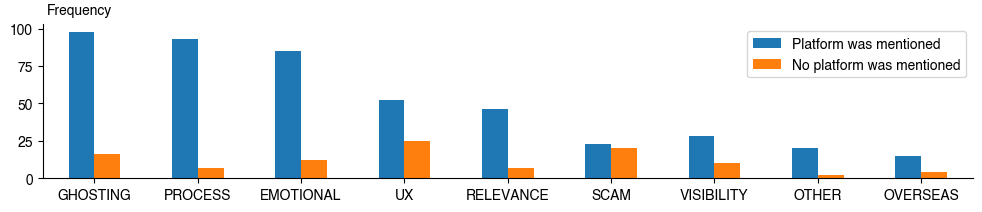

In [42]:
grouped = (
    final_df
    .groupby(['Theme Tag', 'Has Platform'])
    .size()
    .unstack(fill_value=0)
)

grouped.columns = ['Platform was mentioned', 'No platform was mentioned']

# sort by total counts per theme
grouped = grouped.loc[grouped.sum(axis=1).sort_values(ascending=False).index]

fig, axs = plt.subplots(1, 1,figsize=(12, 2))
grouped.plot(kind='bar', ax=axs, rot=0)
#axs.set_xticklabels(axs.get_xticklabels(), rotation=20, ha='right')

axs.set_xlabel('')
axs.set_ylabel('Frequency', rotation=0)
axs.yaxis.set_label_coords(0.04, 1.05)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

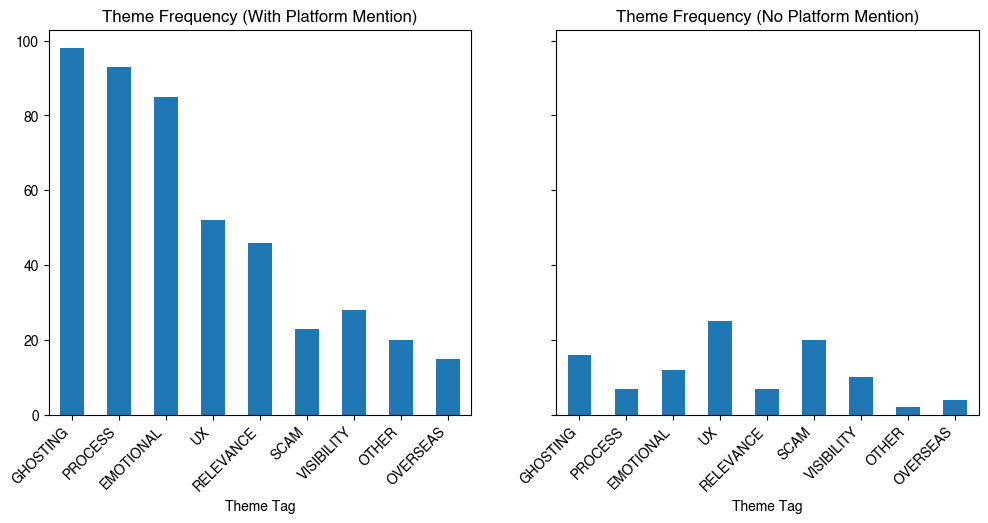

In [43]:
fig, axs = plt.subplots(1, 2, figsize = (12, 5), sharey=True)
grouped['No platform was mentioned'].plot(ax=axs[1], kind='bar', rot=45)
grouped['Platform was mentioned'].plot(ax=axs[0], kind='bar', rot=45)
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right')
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha='right')
axs[1].set_title("Theme Frequency (No Platform Mention)")
axs[0].set_title("Theme Frequency (With Platform Mention)")
plt.show()

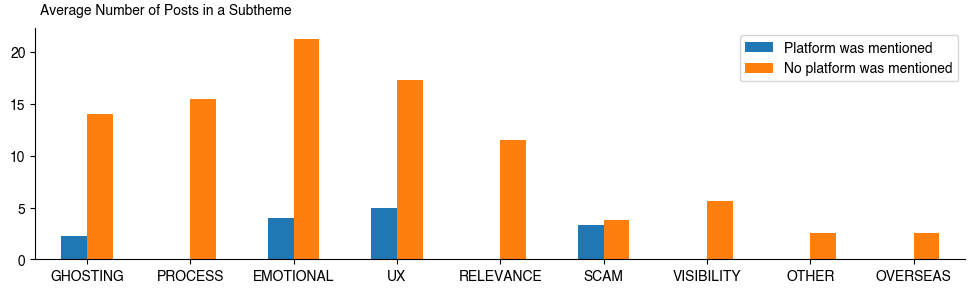

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Your data
data = {
    'GHOSTING': [2.285714286, 14],
    'PROCESS': [0, 15.5],
    'EMOTIONAL': [4, 21.25],
    'UX': [5, 17.33333333],
    'RELEVANCE': [0, 11.5],
    'SCAM': [3.333333333, 3.833333333],
    'VISIBILITY': [0, 5.6],
    'OTHER': [0, 2.5],
    'OVERSEAS': [0, 2.5]
}

index = ['Platform was mentioned', 'No platform was mentioned']

df = pd.DataFrame(data, index=index)

# Apply formal names
df = df.rename(columns=theme_map)

# 🔑 Enforce exact order (same as your table)
ordered_columns = [
    theme_map['GHOSTING'],
    theme_map['PROCESS'],
    theme_map['EMOTIONAL'],
    theme_map['UX'],
    theme_map['RELEVANCE'],
    theme_map['SCAM'],
    theme_map['VISIBILITY'],
    theme_map['OTHER'],
    theme_map['OVERSEAS']
]

df = df[ordered_columns]

# Transpose
grouped = df.T

# Plot
fig, ax = plt.subplots(figsize=(12, 3))
grouped.plot(kind='bar', ax=ax, rot=0)

ax.set_xlabel('')
ax.set_ylabel('Average Number of Posts in a Subtheme', rotation=0)
ax.yaxis.set_label_coords(0.14, 1.05)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()